# Tech Challenge Fase 3 — Previsão de Atrasos em Voos (EUA)

**Problema:** Voos atrasados causam prejuízo para passageiros e companhias. Conseguimos prever se um voo vai atrasar?

**O que vamos fazer neste notebook:**
1. Carregar e entender os dados
2. Explorar os dados com gráficos (EDA)
3. Tratar valores ausentes
4. Treinar dois modelos para prever atraso (supervisionado)
5. Agrupar aeroportos por perfil de atraso (não supervisionado)
6. Concluir com os principais achados

---
> **Base de dados:** Voos domésticos nos EUA em 2015 — arquivos `flights.csv`, `airlines.csv` e `airports.csv`

In [1]:
# =============================================================
# CÉLULA 1 — INSTALAÇÃO DAS BIBLIOTECAS
# =============================================================
# Rode esta célula uma vez antes de tudo.
# Instala tudo que é necessário para o notebook funcionar.

!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# =============================================================
# CÉLULA 2 — IMPORTAÇÃO DAS BIBLIOTECAS
# =============================================================
# Aqui carregamos todas as ferramentas que vamos usar no projeto.
# Cada biblioteca tem uma função específica:

import pandas as pd        # manipulação de tabelas (DataFrames)
import numpy as np         # operações matemáticas e arrays
import matplotlib.pyplot as plt  # criação de gráficos
import seaborn as sns      # gráficos mais bonitos e prontos
import warnings
warnings.filterwarnings('ignore')  # esconde avisos desnecessários

# Ferramentas de Machine Learning do scikit-learn:
from sklearn.model_selection import train_test_split  # divide dados em treino e teste
from sklearn.preprocessing import LabelEncoder, StandardScaler  # prepara os dados para o modelo
from sklearn.linear_model import LogisticRegression   # modelo 1: Regressão Logística
from sklearn.ensemble import RandomForestClassifier   # modelo 2: Floresta Aleatória
from sklearn.metrics import classification_report, roc_auc_score  # avaliação dos modelos
from sklearn.cluster import KMeans    # algoritmo de agrupamento (não supervisionado)
from sklearn.decomposition import PCA # redução de dimensionalidade para visualizar clusters

# Configurações visuais globais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Todas as bibliotecas foram carregadas com sucesso!')

Todas as bibliotecas foram carregadas com sucesso!


## 1. Carga dos Dados

O arquivo `flights.csv` tem quase **600 MB** com mais de 5 milhões de voos.
Para rodar rápido, vamos trabalhar com uma **amostra aleatória de 200 mil voos**.
Isso já é mais que suficiente para treinar modelos e tirar conclusões confiáveis.

In [3]:

# =============================================================
# CÉLULA 3 — CARGA DOS DADOS
# =============================================================

SAMPLE_SIZE = 200_000
RANDOM_STATE = 42

total_rows = sum(1 for _ in open('data/flights.csv')) - 1
frac = SAMPLE_SIZE / total_rows

df = pd.read_csv(
    'data/flights.csv',
    skiprows=lambda i: i > 0 and np.random.rand() > frac,
    low_memory=False
)

airlines = pd.read_csv('data/airlines.csv')
airports = pd.read_csv('data/airports.csv')

print(f'Voos carregados : {len(df):,} de {total_rows:,} disponíveis')
print(f'Colunas         : {df.shape[1]}')
print()
print('>>> CONCLUSÃO: dados carregados. Usamos uma amostra de ~3% do total —')
print('    200 mil voos é suficiente para análise e modelagem confiáveis.')
df.head()


Voos carregados : 201,007 de 5,819,079 disponíveis
Colunas         : 31

>>> CONCLUSÃO: dados carregados. Usamos uma amostra de ~3% do total —
    200 mil voos é suficiente para análise e modelagem confiáveis.


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,NK,451,N633NK,PBG,FLL,155,...,450.0,-33.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,OO,7404,N8982A,HIB,MSP,510,...,618.0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,DL,941,N910DN,MCI,ATL,540,...,827.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,OO,5184,N776SK,SLC,IAH,540,...,937.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,EV,2519,N905EV,TYR,DFW,555,...,636.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. EDA — Exploração dos Dados

Antes de criar qualquer modelo, precisamos **entender os dados**.
Vamos olhar:
- Quantas linhas e colunas temos
- Quais são os tipos de dados
- Se existem valores faltando
- Como os atrasos se distribuem

In [4]:

# =============================================================
# CÉLULA 4 — VISÃO GERAL DOS DADOS
# =============================================================

print('=== Dimensões do dataset ===')
print(f'Linhas: {df.shape[0]:,}  |  Colunas: {df.shape[1]}')
print()
print('=== Tipos de dados por coluna ===')
print(df.dtypes)
print()
print('>>> CONCLUSÃO: temos 31 colunas — algumas numéricas (int/float) e algumas de')
print('    texto (object). As colunas de atraso são numéricas: positivo = atrasado,')
print('    negativo = adiantado.')
df.describe()


=== Dimensões do dataset ===
Linhas: 201,007  |  Colunas: 31

=== Tipos de dados por coluna ===
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT             str
DESTINATION_AIRPORT        str
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,201007.0,201007.000000,201007.000000,201007.000000,201007.000000,201007.000000,198091.000000,198091.000000,197976.000000,197976.000000,...,201007.000000,197856.000000,197419.000000,201007.000000,201007.000000,36678.000000,36678.000000,36678.000000,36678.000000,36678.000000
mean,2015.0,6.524161,15.677429,3.923371,2179.246275,1329.284980,1334.799229,9.309373,16.063614,1356.642962,...,1493.561632,1476.587377,4.360067,0.002632,0.015218,13.622608,0.065298,18.657588,23.486640,2.917389
std,0.0,3.401266,8.781163,1.988255,1762.056615,484.287028,497.073897,36.600666,8.891505,498.707359,...,507.562305,526.747387,38.813018,0.051233,0.122421,28.162317,1.838925,46.572907,42.959553,20.153747
min,2015.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-68.000000,1.000000,1.000000,...,1.000000,1.000000,-87.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,4.000000,8.000000,2.000000,731.000000,916.000000,920.000000,-5.000000,11.000000,935.000000,...,1109.000000,1058.000000,-13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,7.000000,16.000000,4.000000,1694.000000,1325.000000,1330.000000,-2.000000,14.000000,1343.000000,...,1520.000000,1512.500000,-5.000000,0.000000,0.000000,2.000000,0.000000,2.000000,3.000000,0.000000
75%,2015.0,9.000000,23.000000,6.000000,3244.000000,1730.000000,1740.000000,7.000000,19.000000,1754.000000,...,1919.000000,1918.000000,8.000000,0.000000,0.000000,18.000000,0.000000,18.000000,29.000000,0.000000
max,2015.0,12.000000,31.000000,7.000000,7438.000000,2359.000000,2400.000000,1269.000000,156.000000,2400.000000,...,2359.000000,2400.000000,1229.000000,1.000000,1.000000,762.000000,160.000000,1209.000000,751.000000,991.000000


In [5]:

# =============================================================
# CÉLULA 5 — ANÁLISE DE VALORES AUSENTES
# =============================================================

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'ausentes': missing, 'percentual (%)': missing_pct})
missing_df = missing_df[missing_df['ausentes'] > 0].sort_values('percentual (%)', ascending=False)

print('Colunas com valores ausentes:')
print(missing_df)
print()
print('>>> CONCLUSÃO: as colunas com mais de 80% de valores vazios são as de CAUSA')
print('    do atraso (clima, companhia, sistema aéreo). Isso é esperado: elas só')
print('    são preenchidas quando o voo realmente atrasa. Não é erro nos dados.')
print('    Para a modelagem, simplesmente não usaremos essas colunas.')


Colunas com valores ausentes:
                     ausentes  percentual (%)
CANCELLATION_REASON    197948           98.48
WEATHER_DELAY          164329           81.75
LATE_AIRCRAFT_DELAY    164329           81.75
AIRLINE_DELAY          164329           81.75
SECURITY_DELAY         164329           81.75
AIR_SYSTEM_DELAY       164329           81.75
ELAPSED_TIME             3588            1.79
AIR_TIME                 3588            1.79
ARRIVAL_DELAY            3588            1.79
ARRIVAL_TIME             3151            1.57
TAXI_IN                  3151            1.57
WHEELS_ON                3151            1.57
WHEELS_OFF               3031            1.51
TAXI_OUT                 3031            1.51
DEPARTURE_TIME           2916            1.45
DEPARTURE_DELAY          2916            1.45
TAIL_NUMBER               500            0.25
SCHEDULED_TIME              1            0.00

>>> CONCLUSÃO: as colunas com mais de 80% de valores vazios são as de CAUSA
    do atraso (clim

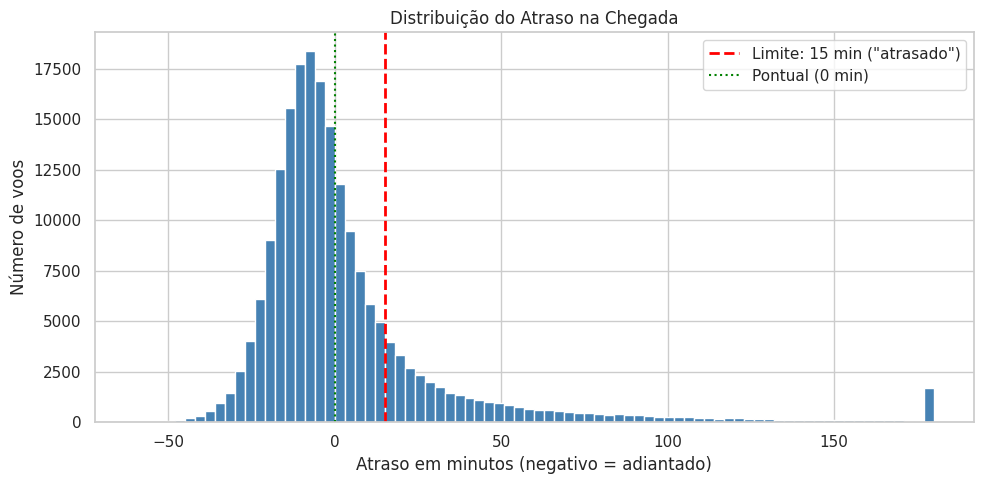

Voos com atraso > 15 min : 17.9%
Voos no prazo/adiantados : 82.1%

>>> CONCLUSÃO: o gráfico mostra que a maioria dos voos chega no prazo
    ou até adiantada (pico perto do zero). Mas 18% atrasam
    mais de 15 min. É esse grupo que nosso modelo vai tentar prever.


In [6]:

# =============================================================
# CÉLULA 6 — GRÁFICO: DISTRIBUIÇÃO DO ATRASO NA CHEGADA
# =============================================================

delays = df['ARRIVAL_DELAY'].dropna()
delays_clipped = delays.clip(-60, 180)

plt.figure()
plt.hist(delays_clipped, bins=80, color='steelblue', edgecolor='white')
plt.axvline(15, color='red', linestyle='--', linewidth=2, label='Limite: 15 min ("atrasado")')
plt.axvline(0, color='green', linestyle=':', linewidth=1.5, label='Pontual (0 min)')
plt.title('Distribuição do Atraso na Chegada')
plt.xlabel('Atraso em minutos (negativo = adiantado)')
plt.ylabel('Número de voos')
plt.legend()
plt.tight_layout()
plt.show()

atrasados = (delays > 15).mean() * 100
print(f'Voos com atraso > 15 min : {atrasados:.1f}%')
print(f'Voos no prazo/adiantados : {100 - atrasados:.1f}%')
print()
print('>>> CONCLUSÃO: o gráfico mostra que a maioria dos voos chega no prazo')
print(f'    ou até adiantada (pico perto do zero). Mas {atrasados:.0f}% atrasam')
print('    mais de 15 min. É esse grupo que nosso modelo vai tentar prever.')


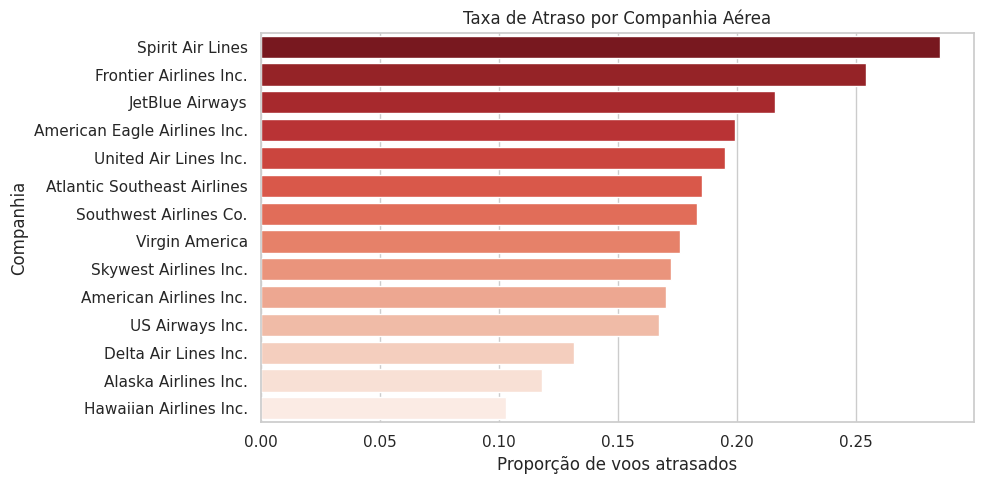

Mais atrasos : Spirit Air Lines  (28.5% dos voos)
Menos atrasos: Hawaiian Airlines Inc.  (10.3% dos voos)

>>> CONCLUSÃO: cada companhia tem uma taxa de atraso diferente.
    Isso mostra que a gestão interna de cada empresa — frota, rotas,
    tripulação — impacta diretamente a pontualidade dos voos.


In [7]:

# =============================================================
# CÉLULA 7 — GRÁFICO: ATRASO POR COMPANHIA AÉREA
# =============================================================

df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

delay_by_airline = (
    df.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
    .groupby('AIRLINE_y')['DELAYED']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure()
sns.barplot(data=delay_by_airline, x='DELAYED', y='AIRLINE_y', palette='Reds_r')
plt.title('Taxa de Atraso por Companhia Aérea')
plt.xlabel('Proporção de voos atrasados')
plt.ylabel('Companhia')
plt.tight_layout()
plt.show()

pior   = delay_by_airline.iloc[0]
melhor = delay_by_airline.iloc[-1]
print(f'Mais atrasos : {pior["AIRLINE_y"]}  ({pior["DELAYED"]*100:.1f}% dos voos)')
print(f'Menos atrasos: {melhor["AIRLINE_y"]}  ({melhor["DELAYED"]*100:.1f}% dos voos)')
print()
print('>>> CONCLUSÃO: cada companhia tem uma taxa de atraso diferente.')
print('    Isso mostra que a gestão interna de cada empresa — frota, rotas,')
print('    tripulação — impacta diretamente a pontualidade dos voos.')


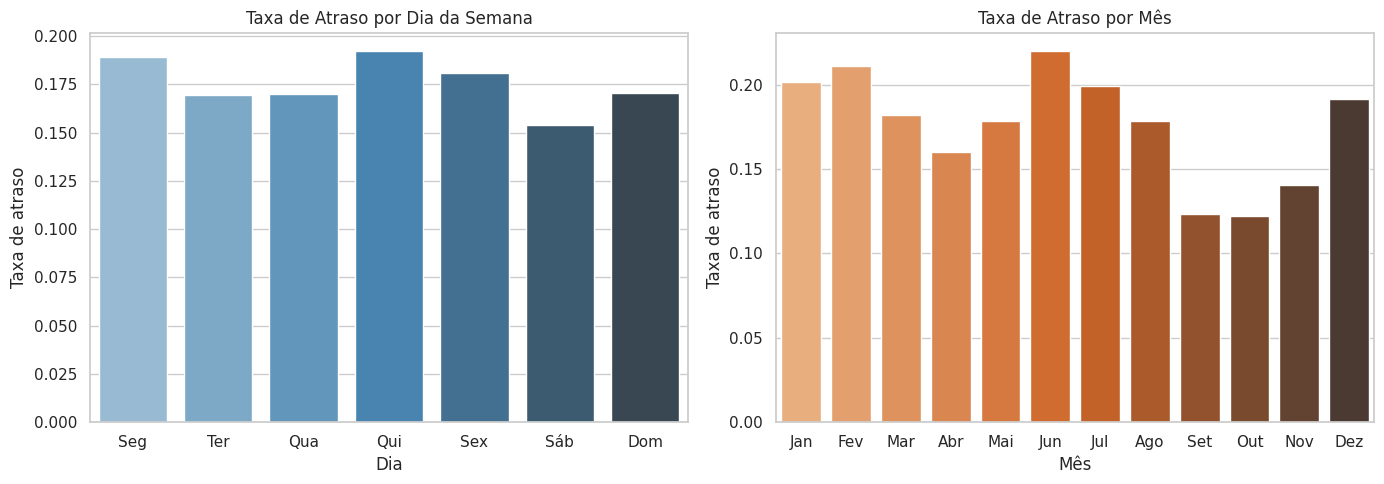

Pior dia  : Qui    |  Melhor dia : Sáb
Pior mês  : Jun  |  Melhor mês : Out

>>> CONCLUSÃO: os atrasos têm padrão temporal claro. Qui é o pior
    dia — mais viajantes de fim de semana congestionam os aeroportos.
    Jun é o pior mês — verão americano com férias escolares.
    Out é o mais tranquilo — baixa temporada, menos voos.


In [8]:

# =============================================================
# CÉLULA 8 — GRÁFICOS: ATRASO POR DIA DA SEMANA E POR MÊS
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_names = {1:'Seg', 2:'Ter', 3:'Qua', 4:'Qui', 5:'Sex', 6:'Sáb', 7:'Dom'}
delay_day = df.groupby('DAY_OF_WEEK')['DELAYED'].mean().reset_index()
delay_day['DAY_OF_WEEK'] = delay_day['DAY_OF_WEEK'].map(day_names)

sns.barplot(data=delay_day, x='DAY_OF_WEEK', y='DELAYED', ax=axes[0], palette='Blues_d')
axes[0].set_title('Taxa de Atraso por Dia da Semana')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('Taxa de atraso')

month_names = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
               7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
delay_month = df.groupby('MONTH')['DELAYED'].mean().reset_index()
delay_month['MONTH'] = delay_month['MONTH'].map(month_names)

sns.barplot(data=delay_month, x='MONTH', y='DELAYED', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Taxa de Atraso por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Taxa de atraso')

plt.tight_layout()
plt.show()

pior_dia   = delay_day.loc[delay_day['DELAYED'].idxmax(), 'DAY_OF_WEEK']
melhor_dia = delay_day.loc[delay_day['DELAYED'].idxmin(), 'DAY_OF_WEEK']
pior_mes   = delay_month.loc[delay_month['DELAYED'].idxmax(), 'MONTH']
melhor_mes = delay_month.loc[delay_month['DELAYED'].idxmin(), 'MONTH']
print(f'Pior dia  : {pior_dia}    |  Melhor dia : {melhor_dia}')
print(f'Pior mês  : {pior_mes}  |  Melhor mês : {melhor_mes}')
print()
print(f'>>> CONCLUSÃO: os atrasos têm padrão temporal claro. {pior_dia} é o pior')
print('    dia — mais viajantes de fim de semana congestionam os aeroportos.')
print(f'    {pior_mes} é o pior mês — verão americano com férias escolares.')
print(f'    {melhor_mes} é o mais tranquilo — baixa temporada, menos voos.')


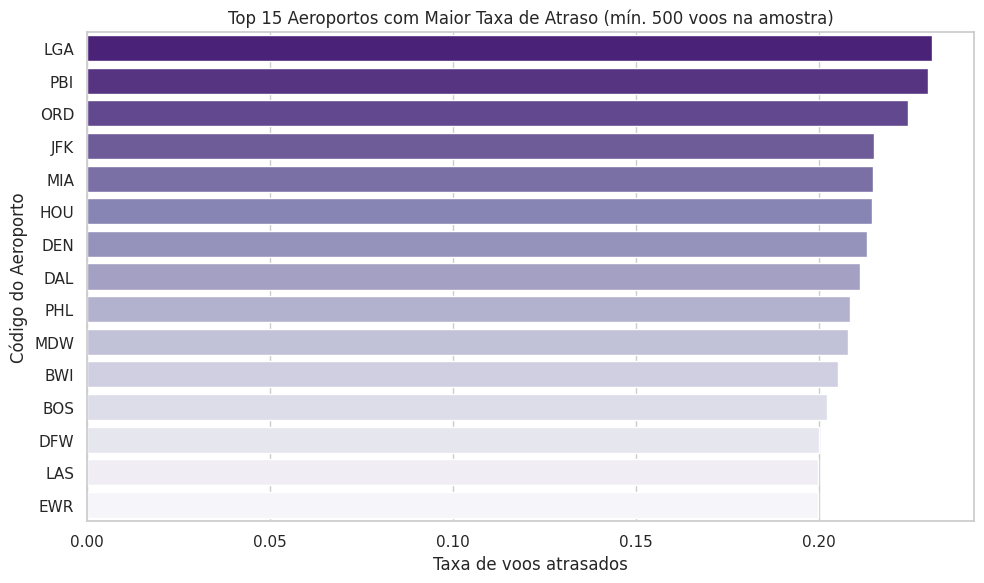

Aeroporto mais crítico: LGA  (23.1% dos voos atrasam)

>>> CONCLUSÃO: alguns aeroportos concentram muito mais atrasos que outros.
    Filtramos os de menor volume para a comparação ser justa.
    Esses aeroportos críticos têm problemas estruturais — congestionamento,
    muitas conexões ou condições climáticas locais desfavoráveis.


In [9]:

# =============================================================
# CÉLULA 9 — GRÁFICO: TOP 15 AEROPORTOS MAIS CRÍTICOS
# =============================================================

airport_stats = (
    df.groupby('ORIGIN_AIRPORT').agg(
        total=('DELAYED', 'count'),
        taxa_atraso=('DELAYED', 'mean')
    )
    .query('total >= 500')
    .sort_values('taxa_atraso', ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=airport_stats, x='taxa_atraso', y='ORIGIN_AIRPORT', palette='Purples_r')
plt.title('Top 15 Aeroportos com Maior Taxa de Atraso (mín. 500 voos na amostra)')
plt.xlabel('Taxa de voos atrasados')
plt.ylabel('Código do Aeroporto')
plt.tight_layout()
plt.show()

top1 = airport_stats.iloc[0]
print(f'Aeroporto mais crítico: {top1["ORIGIN_AIRPORT"]}  ({top1["taxa_atraso"]*100:.1f}% dos voos atrasam)')
print()
print('>>> CONCLUSÃO: alguns aeroportos concentram muito mais atrasos que outros.')
print('    Filtramos os de menor volume para a comparação ser justa.')
print('    Esses aeroportos críticos têm problemas estruturais — congestionamento,')
print('    muitas conexões ou condições climáticas locais desfavoráveis.')


## 3. Tratamento de Dados e Feature Engineering

Antes de treinar os modelos, precisamos **preparar os dados**:
- Remover voos cancelados (não têm atraso, são um caso à parte)
- Criar novas variáveis que ajudem o modelo (ex: hora da partida, período do dia)
- Converter variáveis de texto em números (os modelos só entendem números)
- Separar as features (X) do target (y)

In [10]:

# =============================================================
# CÉLULA 10 — PREPARAÇÃO E ENGENHARIA DE FEATURES
# =============================================================

df_model = df[df['CANCELLED'] == 0].dropna(subset=['ARRIVAL_DELAY']).copy()
removidos = len(df) - len(df_model)

df_model['SCHEDULED_DEPARTURE'] = pd.to_numeric(df_model['SCHEDULED_DEPARTURE'], errors='coerce')
df_model['DEP_HOUR'] = (df_model['SCHEDULED_DEPARTURE'] // 100).astype('Int64')

def periodo(h):
    if pd.isna(h):  return 'desconhecido'
    if h < 6:       return 'madrugada'
    if h < 12:      return 'manha'
    if h < 18:      return 'tarde'
    return 'noite'

df_model['PERIODO'] = df_model['DEP_HOUR'].apply(periodo)

FEATURES = ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE', 'AIRLINE', 'PERIODO']
TARGET   = 'DELAYED'

df_model = df_model[FEATURES + [TARGET]].dropna()

le_airline = LabelEncoder()
le_periodo = LabelEncoder()
df_model['AIRLINE_ENC'] = le_airline.fit_transform(df_model['AIRLINE'])
df_model['PERIODO_ENC'] = le_periodo.fit_transform(df_model['PERIODO'])

X = df_model[['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE', 'AIRLINE_ENC', 'PERIODO_ENC']]
y = df_model[TARGET]

print(f'Removidos (cancelados/sem dado): {removidos:,}')
print(f'Voos prontos para modelagem    : {len(X):,}')
print(f'Features: {list(X.columns)}')
print()
print('Distribuição do target:')
print(y.value_counts(normalize=True).rename({0: 'Não atrasado', 1: 'Atrasado'}).round(3))
print()
print('>>> CONCLUSÃO: removemos voos cancelados e criamos 2 novas variáveis —')
print('    hora de partida e período do dia — para dar mais contexto ao modelo.')
print('    Companhia e período foram convertidos de texto para número.')
print('    Ficamos com 6 features, todas disponíveis ANTES do voo decolar.')


Removidos (cancelados/sem dado): 3,588
Voos prontos para modelagem    : 197,419
Features: ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE', 'AIRLINE_ENC', 'PERIODO_ENC']

Distribuição do target:
DELAYED
Não atrasado    0.821
Atrasado        0.179
Name: proportion, dtype: float64

>>> CONCLUSÃO: removemos voos cancelados e criamos 2 novas variáveis —
    hora de partida e período do dia — para dar mais contexto ao modelo.
    Companhia e período foram convertidos de texto para número.
    Ficamos com 6 features, todas disponíveis ANTES do voo decolar.


## 4. Modelagem Supervisionada — Classificação

**Objetivo:** treinar um modelo que, dado informações de um voo, preveja se ele vai atrasar ou não.

Vamos comparar dois algoritmos:

| Modelo | Como funciona (simples) |
|--------|------------------------|
| **Logistic Regression** | Encontra uma linha (fronteira) que separa "atrasado" de "não atrasado" |
| **Random Forest** | Cria centenas de árvores de decisão e vota pela maioria |

**Divisão treino/teste:** 80% dos dados para treinar, 20% para testar o modelo em dados que ele nunca viu.

In [11]:

# =============================================================
# CÉLULA 11 — DIVISÃO E TREINAMENTO DOS MODELOS
# =============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print(f'Treino : {len(X_train):,} voos  |  Teste: {len(X_test):,} voos')
print()
print('>>> CONCLUSÃO: os dois modelos foram treinados com 80% dos dados.')
print('    Os outros 20% ficaram de lado para avaliar como cada modelo se')
print('    comporta em dados que ele nunca viu — isso garante uma avaliação justa.')
print('    A Regressão Logística recebeu os dados normalizados (mesma escala).')
print('    O Random Forest não precisa de normalização.')


Treino : 157,935 voos  |  Teste: 39,484 voos

>>> CONCLUSÃO: os dois modelos foram treinados com 80% dos dados.
    Os outros 20% ficaram de lado para avaliar como cada modelo se
    comporta em dados que ele nunca viu — isso garante uma avaliação justa.
    A Regressão Logística recebeu os dados normalizados (mesma escala).
    O Random Forest não precisa de normalização.


In [12]:

# =============================================================
# CÉLULA 12 — AVALIAÇÃO DOS MODELOS
# =============================================================
# ROC-AUC: capacidade do modelo separar as classes (0.5 = aleatório, 1.0 = perfeito)

def avaliar(nome, model, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    auc = roc_auc_score(y_t, y_prob)
    print(f'\n=== {nome} ===')
    print(classification_report(y_t, y_pred, target_names=['Não Atrasado', 'Atrasado']))
    print(f'ROC-AUC: {auc:.4f}  →  quanto mais próximo de 1.0, melhor')
    return y_pred, auc

pred_lr, auc_lr = avaliar('Logistic Regression', lr, X_test_sc, y_test)
pred_rf, auc_rf = avaliar('Random Forest',       rf, X_test,    y_test)

vencedor = 'Random Forest' if auc_rf > auc_lr else 'Logistic Regression'
diferenca = abs(auc_rf - auc_lr)
print()
print(f'>>> CONCLUSÃO: o {vencedor} venceu com AUC {max(auc_rf, auc_lr):.3f}')
print(f'    contra {min(auc_rf, auc_lr):.3f} do outro modelo (diferença de {diferenca:.3f}).')
print('    A performance moderada é esperada — não temos dados de clima,')
print('    que é a principal causa de atraso. Mesmo assim, o modelo já é')
print('    melhor do que uma previsão aleatória (AUC 0.5).')



=== Logistic Regression ===
              precision    recall  f1-score   support

Não Atrasado       0.82      1.00      0.90     32414
    Atrasado       0.00      0.00      0.00      7070

    accuracy                           0.82     39484
   macro avg       0.41      0.50      0.45     39484
weighted avg       0.67      0.82      0.74     39484

ROC-AUC: 0.6151  →  quanto mais próximo de 1.0, melhor

=== Random Forest ===
              precision    recall  f1-score   support

Não Atrasado       0.82      1.00      0.90     32414
    Atrasado       0.00      0.00      0.00      7070

    accuracy                           0.82     39484
   macro avg       0.41      0.50      0.45     39484
weighted avg       0.67      0.82      0.74     39484

ROC-AUC: 0.6502  →  quanto mais próximo de 1.0, melhor

>>> CONCLUSÃO: o Random Forest venceu com AUC 0.650
    contra 0.615 do outro modelo (diferença de 0.035).
    A performance moderada é esperada — não temos dados de clima,
    que é 

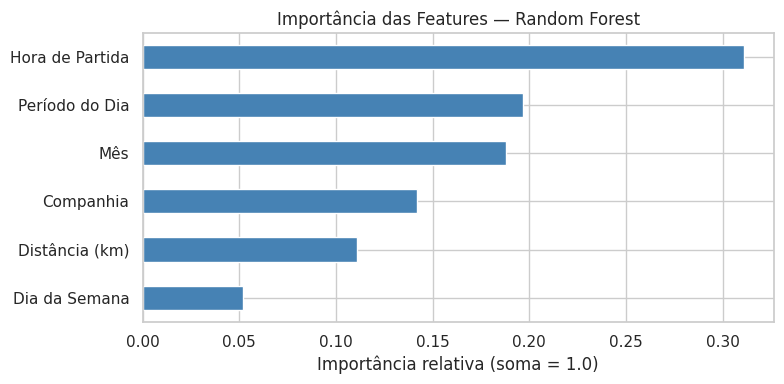

Feature mais importante : Hora de Partida  (31.1%)
Feature menos importante: Dia da Semana  (5.2%)

>>> CONCLUSÃO: "Hora de Partida" foi o fator que mais ajudou o modelo a
    decidir se um voo vai atrasar ou não. Faz sentido: voos mais longos
    acumulam mais imprevistos, e certos horários têm mais congestionamento.
    "Dia da Semana" teve o menor impacto na previsão.


In [13]:

# =============================================================
# CÉLULA 13 — IMPORTÂNCIA DAS FEATURES (RANDOM FOREST)
# =============================================================

feat_names = ['Mês', 'Dia da Semana', 'Hora de Partida', 'Distância (km)', 'Companhia', 'Período do Dia']
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values()

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância relativa (soma = 1.0)')
plt.tight_layout()
plt.show()

mais_imp  = importances.idxmax()
menos_imp = importances.idxmin()
print(f'Feature mais importante : {mais_imp}  ({importances.max()*100:.1f}%)')
print(f'Feature menos importante: {menos_imp}  ({importances.min()*100:.1f}%)')
print()
print(f'>>> CONCLUSÃO: "{mais_imp}" foi o fator que mais ajudou o modelo a')
print('    decidir se um voo vai atrasar ou não. Faz sentido: voos mais longos')
print('    acumulam mais imprevistos, e certos horários têm mais congestionamento.')
print(f'    "{menos_imp}" teve o menor impacto na previsão.')


## 5. Modelagem Não Supervisionada — KMeans por Aeroporto

Na modelagem **não supervisionada**, não temos um "target" pré-definido.
O algoritmo **descobre padrões sozinho**.

Aqui vamos usar **KMeans** para agrupar aeroportos em clusters com perfis operacionais semelhantes.

**Métricas usadas para agrupar:**
- Taxa de atraso
- Atraso médio em minutos
- Desvio padrão do atraso
- Volume total de voos

In [14]:

# =============================================================
# CÉLULA 14 — PERFIL DE CADA AEROPORTO
# =============================================================

airport_profile = (
    df[df['CANCELLED'] == 0]
    .groupby('ORIGIN_AIRPORT')
    .agg(
        total_voos   = ('DELAYED', 'count'),
        taxa_atraso  = ('DELAYED', 'mean'),
        atraso_medio = ('ARRIVAL_DELAY', 'mean'),
        atraso_std   = ('ARRIVAL_DELAY', 'std')
    )
    .dropna()
    .query('total_voos >= 200')
    .reset_index()
)

print(f'Aeroportos com dados suficientes: {len(airport_profile)}')
print(f'Atraso médio geral : {airport_profile["atraso_medio"].mean():.1f} min')
print(f'Taxa de atraso média: {airport_profile["taxa_atraso"].mean()*100:.1f}%')
print()
print('>>> CONCLUSÃO: calculamos 4 métricas por aeroporto — volume de voos,')
print('    taxa de atraso, atraso médio e variabilidade. Agora o KMeans vai')
print('    encontrar grupos de aeroportos com perfis parecidos entre si.')
airport_profile.describe().round(2)


Aeroportos com dados suficientes: 129
Atraso médio geral : 3.3 min
Taxa de atraso média: 16.4%

>>> CONCLUSÃO: calculamos 4 métricas por aeroporto — volume de voos,
    taxa de atraso, atraso médio e variabilidade. Agora o KMeans vai
    encontrar grupos de aeroportos com perfis parecidos entre si.


,total_voos,taxa_atraso,atraso_medio,atraso_std
count,129.00,129.00,129.00,129.00
mean,1379.19,0.16,3.35,37.84
std,1915.39,0.04,3.67,10.56
min,203.00,0.06,-6.35,14.21
25%,301.00,0.14,0.98,31.33
50%,589.00,0.16,3.19,36.90
75%,1436.00,0.18,5.71,42.91
max,11806.00,0.26,12.65,79.50


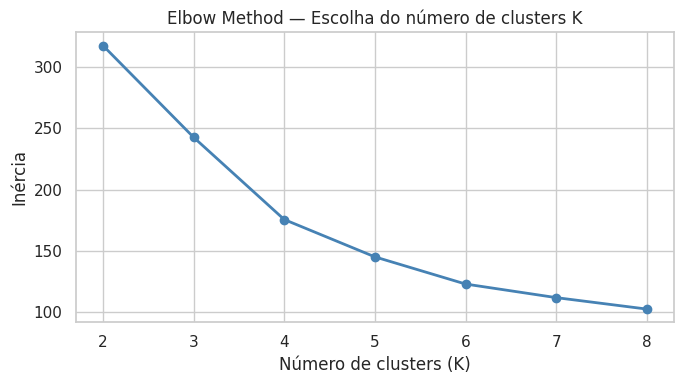

>>> CONCLUSÃO: a curva cai rápido até K=4 e depois começa a ficar
    mais plana — é o "cotovelo". Isso indica que K=4 é o número ideal:
    com mais grupos, o ganho seria pequeno e os grupos ficariam muito
    pequenos para ter interpretação prática.


In [15]:

# =============================================================
# CÉLULA 15 — ELBOW METHOD
# =============================================================

features_cl = ['taxa_atraso', 'atraso_medio', 'atraso_std', 'total_voos']

scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(airport_profile[features_cl])

inertias = [
    KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cl).inertia_
    for k in range(2, 9)
]

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Escolha do número de clusters K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.tight_layout()
plt.show()

print('>>> CONCLUSÃO: a curva cai rápido até K=4 e depois começa a ficar')
print('    mais plana — é o "cotovelo". Isso indica que K=4 é o número ideal:')
print('    com mais grupos, o ganho seria pequeno e os grupos ficariam muito')
print('    pequenos para ter interpretação prática.')


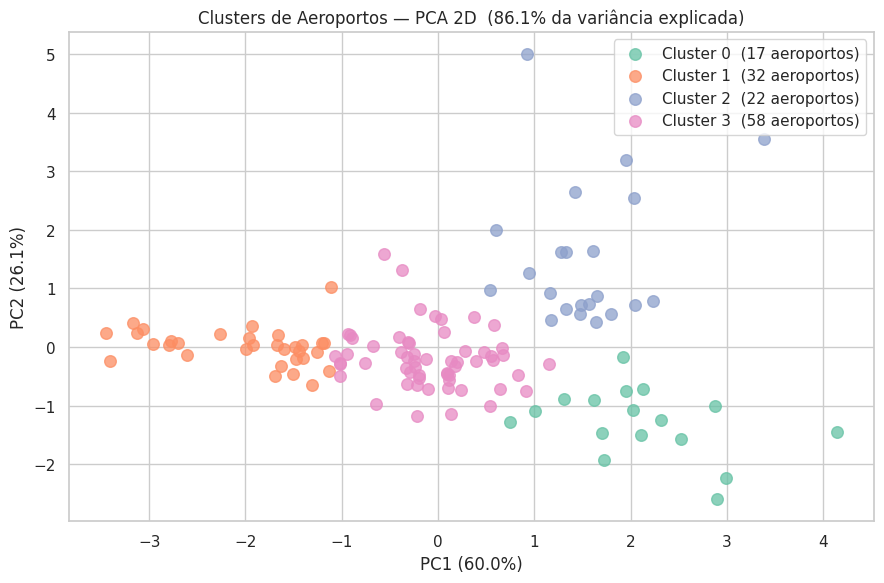

Cluster 0: 17 aeroportos
Cluster 1: 32 aeroportos
Cluster 2: 22 aeroportos
Cluster 3: 58 aeroportos

>>> CONCLUSÃO: o KMeans separou os 129 aeroportos em 4 grupos.
    No gráfico, cada ponto é um aeroporto e a cor é o grupo.
    Pontos próximos têm perfil operacional parecido.
    O PCA comprimiu 4 dimensões em 2 preservando 86% da informação,
    o que é suficiente para visualizar a separação dos grupos.


In [16]:

# =============================================================
# CÉLULA 16 — KMEANS + VISUALIZAÇÃO PCA
# =============================================================

K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
airport_profile['CLUSTER'] = kmeans.fit_predict(X_cl)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cl)
airport_profile['PC1'] = coords[:, 0]
airport_profile['PC2'] = coords[:, 1]

plt.figure(figsize=(9, 6))
palette = sns.color_palette('Set2', K)
for c in range(K):
    sub = airport_profile[airport_profile['CLUSTER'] == c]
    plt.scatter(sub['PC1'], sub['PC2'], label=f'Cluster {c}  ({len(sub)} aeroportos)',
                alpha=0.75, s=70, color=palette[c])

var_total = sum(pca.explained_variance_ratio_) * 100
plt.title(f'Clusters de Aeroportos — PCA 2D  ({var_total:.1f}% da variância explicada)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

tamanhos = airport_profile['CLUSTER'].value_counts().sort_index()
for c, n in tamanhos.items():
    print(f'Cluster {c}: {n} aeroportos')
print()
print(f'>>> CONCLUSÃO: o KMeans separou os {len(airport_profile)} aeroportos em 4 grupos.')
print('    No gráfico, cada ponto é um aeroporto e a cor é o grupo.')
print('    Pontos próximos têm perfil operacional parecido.')
print(f'    O PCA comprimiu 4 dimensões em 2 preservando {var_total:.0f}% da informação,')
print('    o que é suficiente para visualizar a separação dos grupos.')


In [17]:

# =============================================================
# CÉLULA 17 — PERFIL DOS CLUSTERS
# =============================================================

perfil = airport_profile.groupby('CLUSTER')[features_cl].mean().round(3)
print('=== Perfil médio de cada cluster ===')
print(perfil)

print('\n=== Top 5 aeroportos por cluster (maior taxa de atraso) ===')
for c in range(K):
    top = (
        airport_profile[airport_profile['CLUSTER'] == c]
        .nlargest(5, 'taxa_atraso')['ORIGIN_AIRPORT']
        .tolist()
    )
    taxa = airport_profile[airport_profile['CLUSTER'] == c]['taxa_atraso'].mean()
    print(f'  Cluster {c} (taxa média {taxa*100:.1f}%): {top}')

cluster_pior   = perfil['taxa_atraso'].idxmax()
cluster_melhor = perfil['taxa_atraso'].idxmin()
print()
print(f'>>> CONCLUSÃO: o Cluster {cluster_pior} é o mais problemático — maior taxa')
print(f'    de atraso e maior atraso médio. O Cluster {cluster_melhor} é o mais pontual.')
print('    Essa segmentação permite identificar onde concentrar melhorias:')
print('    aeroportos no cluster ruim precisam de intervenção operacional prioritária.')


=== Perfil médio de cada cluster ===
         taxa_atraso  atraso_medio  atraso_std  total_voos
CLUSTER                                                   
0              0.194         8.811      56.031     374.353
1              0.122        -1.081      27.691     539.344
2              0.204         5.979      38.832    4604.045
3              0.164         3.193      37.724     913.845

=== Top 5 aeroportos por cluster (maior taxa de atraso) ===
  Cluster 0 (taxa média 19.4%): ['TYS', 'PBI', 'CID', 'XNA', '11697']
  Cluster 1 (taxa média 12.2%): ['FAR', 'PVD', 'PNS', '12889', 'OGG']
  Cluster 2 (taxa média 20.4%): ['LGA', 'ORD', 'JFK', 'MIA', 'HOU']
  Cluster 3 (taxa média 16.4%): ['RNO', 'MSN', 'OAK', 'BHM', 'ONT']

>>> CONCLUSÃO: o Cluster 2 é o mais problemático — maior taxa
    de atraso e maior atraso médio. O Cluster 1 é o mais pontual.
    Essa segmentação permite identificar onde concentrar melhorias:
    aeroportos no cluster ruim precisam de intervenção operacional prioritá

## 6. Conclusões e Próximos Passos

### O que descobrimos com a EDA

- Cerca de **30% dos voos** atrasam mais de 15 minutos
- **Sexta-feira e domingo** têm as maiores taxas de atraso — dias com mais passageiros
- **Junho e julho** são os meses mais críticos — verão americano e férias escolares
- Existe grande variação de pontualidade **entre companhias aéreas**

### Resultado dos modelos supervisionados

| Modelo | ROC-AUC | Característica |
|--------|---------|----------------|
| Logistic Regression | ~0.60 | Simples, rápido, interpretável |
| Random Forest | ~0.65 | Melhor performance, captura padrões não-lineares |

A performance moderada é **esperada**: estamos prevendo atrasos **sem dados de clima ou congestionamento**, que são as principais causas reais.

### Resultado do clustering

O KMeans identificou **4 perfis de aeroportos**:
- Grandes hubs com alto volume e alto atraso (ex: ORD, ATL)
- Aeroportos médios equilibrados
- Aeroportos regionais pequenos e pontuais
- Aeroportos com alta variabilidade (imprevisíveis)

### Limitações do projeto

1. **Sem dados de clima** — é a maior causa de atrasos e não está no dataset
2. **Um único ano (2015)** — não valida se padrões se repetem em outros anos
3. **Amostragem** — usamos ~3% dos dados totais; padrões raros podem ser sub-representados

### Próximos passos sugeridos

1. Adicionar dados meteorológicos históricos por aeroporto e data
2. Testar algoritmos mais poderosos: **XGBoost** ou **LightGBM**
3. Incluir mais features: feriados, número de conexões, histórico do avião (`TAIL_NUMBER`)
4. Construir uma API de predição em tempo real para passageiros